In [1]:
# Leer archivo bateria_tableta.txt como csv.

import pandas as pd

datos = pd.read_csv("bateria_tableta.txt")

print(datos)

    carga  duracion
0    2.81      5.62
1    7.14      8.00
2    2.72      5.44
3    3.87      7.74
4    1.90      3.80
..    ...       ...
95   4.38      8.00
96   8.06      8.00
97   8.05      8.00
98   1.10      2.20
99   6.65      8.00

[100 rows x 2 columns]


In [2]:
datos.shape # Renglones y columnas

(100, 2)

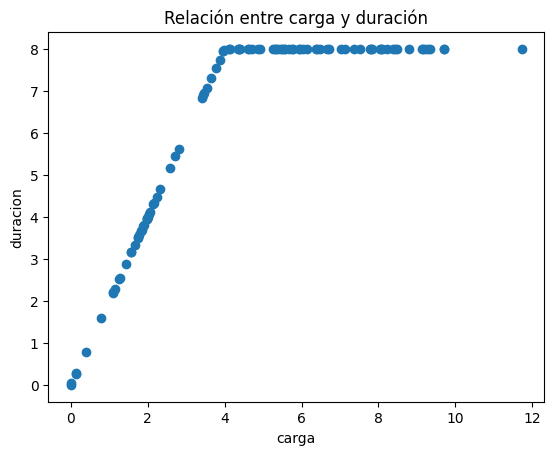

In [3]:
# Crear tabla de bateria_tableta con los datos

import matplotlib.pyplot as plt

# Creación de figuras con scatter plot

plt.scatter(datos['carga'], datos['duracion'])
plt.xlabel('carga')
plt.ylabel('duracion')
plt.title('Relación entre carga y duración')
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit?

Signature: lr.fit(X, y, sample_weight=None)
Docstring:
Fit linear model.

Parameters
----------
X : {array-like, sparse matrix} of shape (n_samples, n_features)
    Training data.

y : array-like of shape (n_samples,) or (n_samples, n_targets)
    Target values. Will be cast to X's dtype if necessary.

sample_weight : array-like of shape (n_samples,), default=None
    Individual weights for each sample.

    .. versionadded:: 0.17
       parameter *sample_weight* support to LinearRegression.

Returns
-------
self : object
    Fitted Estimator.
File:      c:\users\carlo\appdata\local\programs\python\python312\lib\site-packages\sklearn\linear_model\_base.py
Type:      method

In [ ]:
lr.fit(

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
import numpy as np

X = np.reshape?

Signature:       np.reshape(a, /, shape, order='C', *, copy=None)
Call signature:  np.reshape(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function reshape at 0x00000239CA0B8EA0>
File:            c:\users\carlo\appdata\local\programs\python\python312\lib\site-packages\numpy\_core\fromnumeric.py
Docstring:      
Gives a new shape to an array without changing its data.

Parameters
----------
a : array_like
    Array to be reshaped.
shape : int or tuple of ints
    The new shape should be compatible with the original shape. If
    an integer, then the result will be a 1-D array of that length.
    One shape dimension can be -1. In this case, the value is
    inferred from the length of the array and remaining dimensions.
order : {'C', 'F', 'A'}, optional
    Read the elements of ``a`` using this index order, and place the
    elements into the reshaped array using this index order. 'C'
    means to read / write the elements using C-like index order,
    wit

In [17]:
X_v = np.reshape(datos['carga'].values, (-1, 1))
X2_v = X_v ** 2


In [20]:
np.ones?

Signature: np.ones(shape, dtype=None, order='C', *, device=None, like=None)
Docstring:
Return a new array of given shape and type, filled with ones.

Parameters
----------
shape : int or sequence of ints
    Shape of the new array, e.g., ``(2, 3)`` or ``2``.
dtype : data-type, optional
    The desired data-type for the array, e.g., `numpy.int8`.  Default is
    `numpy.float64`.
order : {'C', 'F'}, optional, default: C
    Whether to store multi-dimensional data in row-major
    (C-style) or column-major (Fortran-style) order in
    memory.
device : str, optional
    The device on which to place the created array. Default: None.
    For Array-API interoperability only, so must be ``"cpu"`` if passed.

    .. versionadded:: 2.0.0
like : array_like, optional
    Reference object to allow the creation of arrays which are not
    NumPy arrays. If an array-like passed in as ``like`` supports
    the ``__array_function__`` protocol, the result will be defined
    by it. In this case, it ensur

In [23]:
ones =np.ones([100,1])

In [22]:
np.hstack?

Signature:       np.hstack(tup, *, dtype=None, casting='same_kind')
Call signature:  np.hstack(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function hstack at 0x00000239CA0C4720>
File:            c:\users\carlo\appdata\local\programs\python\python312\lib\site-packages\numpy\_core\shape_base.py
Docstring:      
Stack arrays in sequence horizontally (column wise).

This is equivalent to concatenation along the second axis, except for 1-D
arrays where it concatenates along the first axis. Rebuilds arrays divided
by `hsplit`.

This function makes most sense for arrays with up to 3 dimensions. For
instance, for pixel-data with a height (first axis), width (second axis),
and r/g/b channels (third axis). The functions `concatenate`, `stack` and
`block` provide more general stacking and concatenation operations.

Parameters
----------
tup : sequence of ndarrays
    The arrays must have the same shape along all but the second axis,
    except 1-D arrays which can

In [35]:
# np.hstack([ones, X_v, X2_v]) # Matriz de X

# Se borra "ones" porque se asume que la librería de sklearn ya lo hace automáticamente.

X = np.hstack([X_v, X2_v])

In [37]:
lr.fit(X, datos['duracion'].values)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
lr.intercept_ # Intercepto, B0

np.float64(0.1091917907649469)

In [ ]:
lr.coef_ # B1, B2

array([ 2.34328352, -0.16141513])

El modelo queda como: 0.1091 + 2.3432x - 0.1614x2

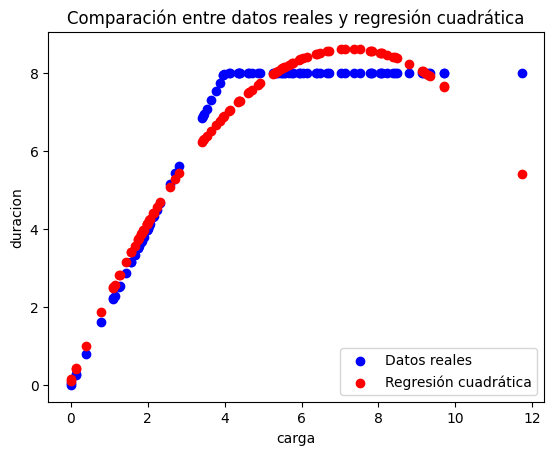

In [42]:
# Creación de la gráfica de comparación entre los datos y la regresión cuadrática

plt.scatter(X_v, datos['duracion'].values, color='blue', label='Datos reales')
plt.scatter(X_v, lr.predict(X), color='red', label='Regresión cuadrática')
plt.xlabel('carga')
plt.ylabel('duracion')
plt.title('Comparación entre datos reales y regresión cuadrática')
plt.legend()
plt.show()

In [44]:
R2 = lr.score(X, datos['duracion'].values)
R2

0.9548893873285215